## Постановка задачи

Предсказание оттока пользователей телеком-компании.

**Размер датасета**:
**Строки:** 7043
**Столбцы:** 21

**Названия столбцов:**

* **CustomerID**: идентификатор клиента
* **Gender**: пол (Male/Female)
* **SeniorCitizen**: пожилой клиент, пенсионер (0 = No, 1 = Yes)
* **Partner**: есть супруг(а) (Yes/No)
* **Dependents**: есть иждивенцы (Yes/No)
* **Tenure**: количество месяцев с компанией
* **PhoneService**: подключена телефонная связь (Yes/No)
* **MultipleLines**: несколько линий (Yes/No/No phone service)
* **InternetService**: тип интернета (DSL/Fiber optic/No)
* **OnlineSecurity**, **OnlineBackup**, **DeviceProtection**, **TechSupport**, **StreamingTV**, **StreamingMovies**: дополнительные интернет-услуги (Yes/No/No internet service)
* **Contract**: тип контракта (Month-to-month/One year/Two year)
* **PaperlessBilling**: получение счетов или платежных документов в электронном виде (Yes/No)
* **PaymentMethod**: способ оплаты (Electronic check/Mailed check/Bank transfer/Credit card)
* **MonthlyCharges**: ежемесячная сумма оплаты
* **TotalCharges**: общая сумма оплат за всё время
* **Churn**: ушёл ли клиент (Yes/No)


## Импорт библиотек

In [ ]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [ ]:
import random
import numpy as np
import pandas as pd

from plots import (
    plot_hist_numeric,
    plot_hist_categorical,
    plot_all_categorical,
    plot_phik,
    plot_categorical_relationship,
    plot_numeric_relationship,
    plot_numeric_vs_categorical_boxplot
)

In [ ]:
# фиксируем состояние генератора псевдослучайных чисел.
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

## 1. Изучение структуры данных

In [ ]:
df = pd.read_csv("./Telecom_Customer_Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


На первый взгляд пропущенных значений нет, правда столбец TotalCharges имеет тип данных object вместо float64. Нужно изучить его внимательнее

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Проверка на корректность и качество данных

### 2.1 Проверка на дубликаты

In [ ]:
df.duplicated().sum() 

np.int64(0)

Дубликатов нет

### 2.2 Пропущенные значения

In [ ]:
# Приведем столбец TotalCharges к типу float. Если значение нельзя перевести к float оно заменится на NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df.isna().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Везде где столбец TotalCharges имеет пропуски, Tenure (количество месяцев с компанией) равно 0. Значит правильнее будет заменить все пропуски в TotalCharges на 0

In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 2.3 Корректность по столбцам

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Отрицательных значений нет

In [ ]:
numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())
    print("-"*50)

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
---------------------------------------

Лишних значений в категориальных признаках нет

## 3. Детальное изучение признаков (и таргета)

In [ ]:
NUMERICAL_FEATURES_LIST = ["tenure", "MonthlyCharges", "TotalCharges"]

CATEGORICAL_FEATURES_LIST = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

TARGET = "Churn"

### 3.1 Числовые переменные

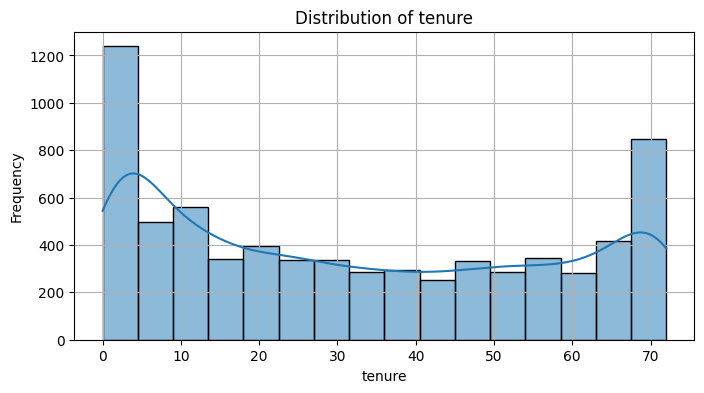

In [ ]:
plot_hist_numeric(df, 'tenure')

Распределение признака **tenure** (количество месяцев с компанией) выглядит **двухвершинным (U-образным)** и **неравномерным**.

**Две крупные группы наблюдений:**
   - Первая - вблизи **нулевых значений** tenure: много клиентов с очень малым сроком пребывания.
   - Вторая - вблизи **максимальных значений** (около 70): значительная доля клиентов, находящихся в компании очень долго.

**Между этими вершинами (от примерно 10 до 60 месяцев)** заметен **спад частоты** - таких клиентов меньше.

**Форма распределения:**
   - **Не является нормальным** и **асимметрично (раздвоено)**.
   - Можно сказать, что это **смесь двух подраспределений** - новых клиентов и лояльных старых.

**Интерпретация:**
   - Компания, вероятно, часто привлекает новых клиентов, но также удерживает часть аудитории на долгий срок.
   - Среднесрочные клиенты (например, с 10–50 месяцев срока пребывания) составляют меньшую долю, возможно, из-за оттока в этот период.

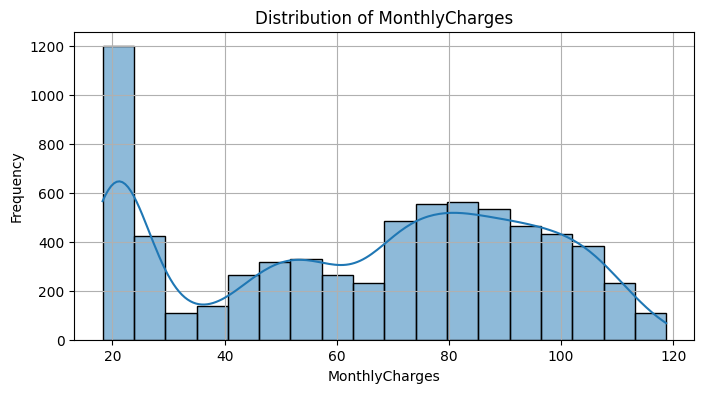

In [ ]:
plot_hist_numeric(df, 'MonthlyCharges')

График распределения признака **MonthlyCharges** (ежемесячные платежи клиентов).  

**Форма распределения:**  
   Распределение **мультимодальное** (имеет несколько пиков).  
   - Один выраженный пик находится на **низких значениях (~20)** - клиенты с минимальными тарифами (базовые услуги).  
   - Второй, более широкий пик — примерно в диапазоне **70–100** - клиенты, которые платят больше (вероятно, за расширенные пакеты).

**Характер распределения:**  
   - Большая часть клиентов имеет **низкие или средние платежи**, а доля клиентов с дорогими тарифами постепенно снижается.
   - При этом просматривается небольшой «провал» между 30 и 60 - возможно, промежуточные тарифы менее популярны.

**Интерпретация:**  
   - Есть чёткие группы клиентов: **экономные** (20–30) и **премиальные** (70–100).  
   - Возможно, компания предлагает **пакетную структуру тарифов**, где много людей либо выбирают минимальный план, либо переходят на дорогие премиум пакеты, а средние варианты менее востребованы.

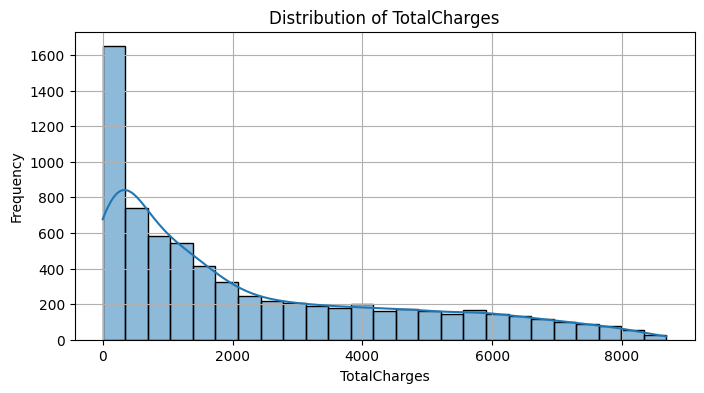

In [ ]:
plot_hist_numeric(df, 'TotalCharges')

График распределения признака **TotalCharges** (общая сумма платежей клиента за всё время обслуживания).  

**Сильная положительная асимметрия (правосторонняя)**  

**Возможные причины пика у нуля:**
   - Клиенты, которые только зарегистрировались.  
   - Клиенты, оплатившие только первый месяц или ещё не произвели оплату.

**Вывод:**
   - использовать **логарифмическое преобразование** для симметризации.

### 3.2 Категориальные переменные

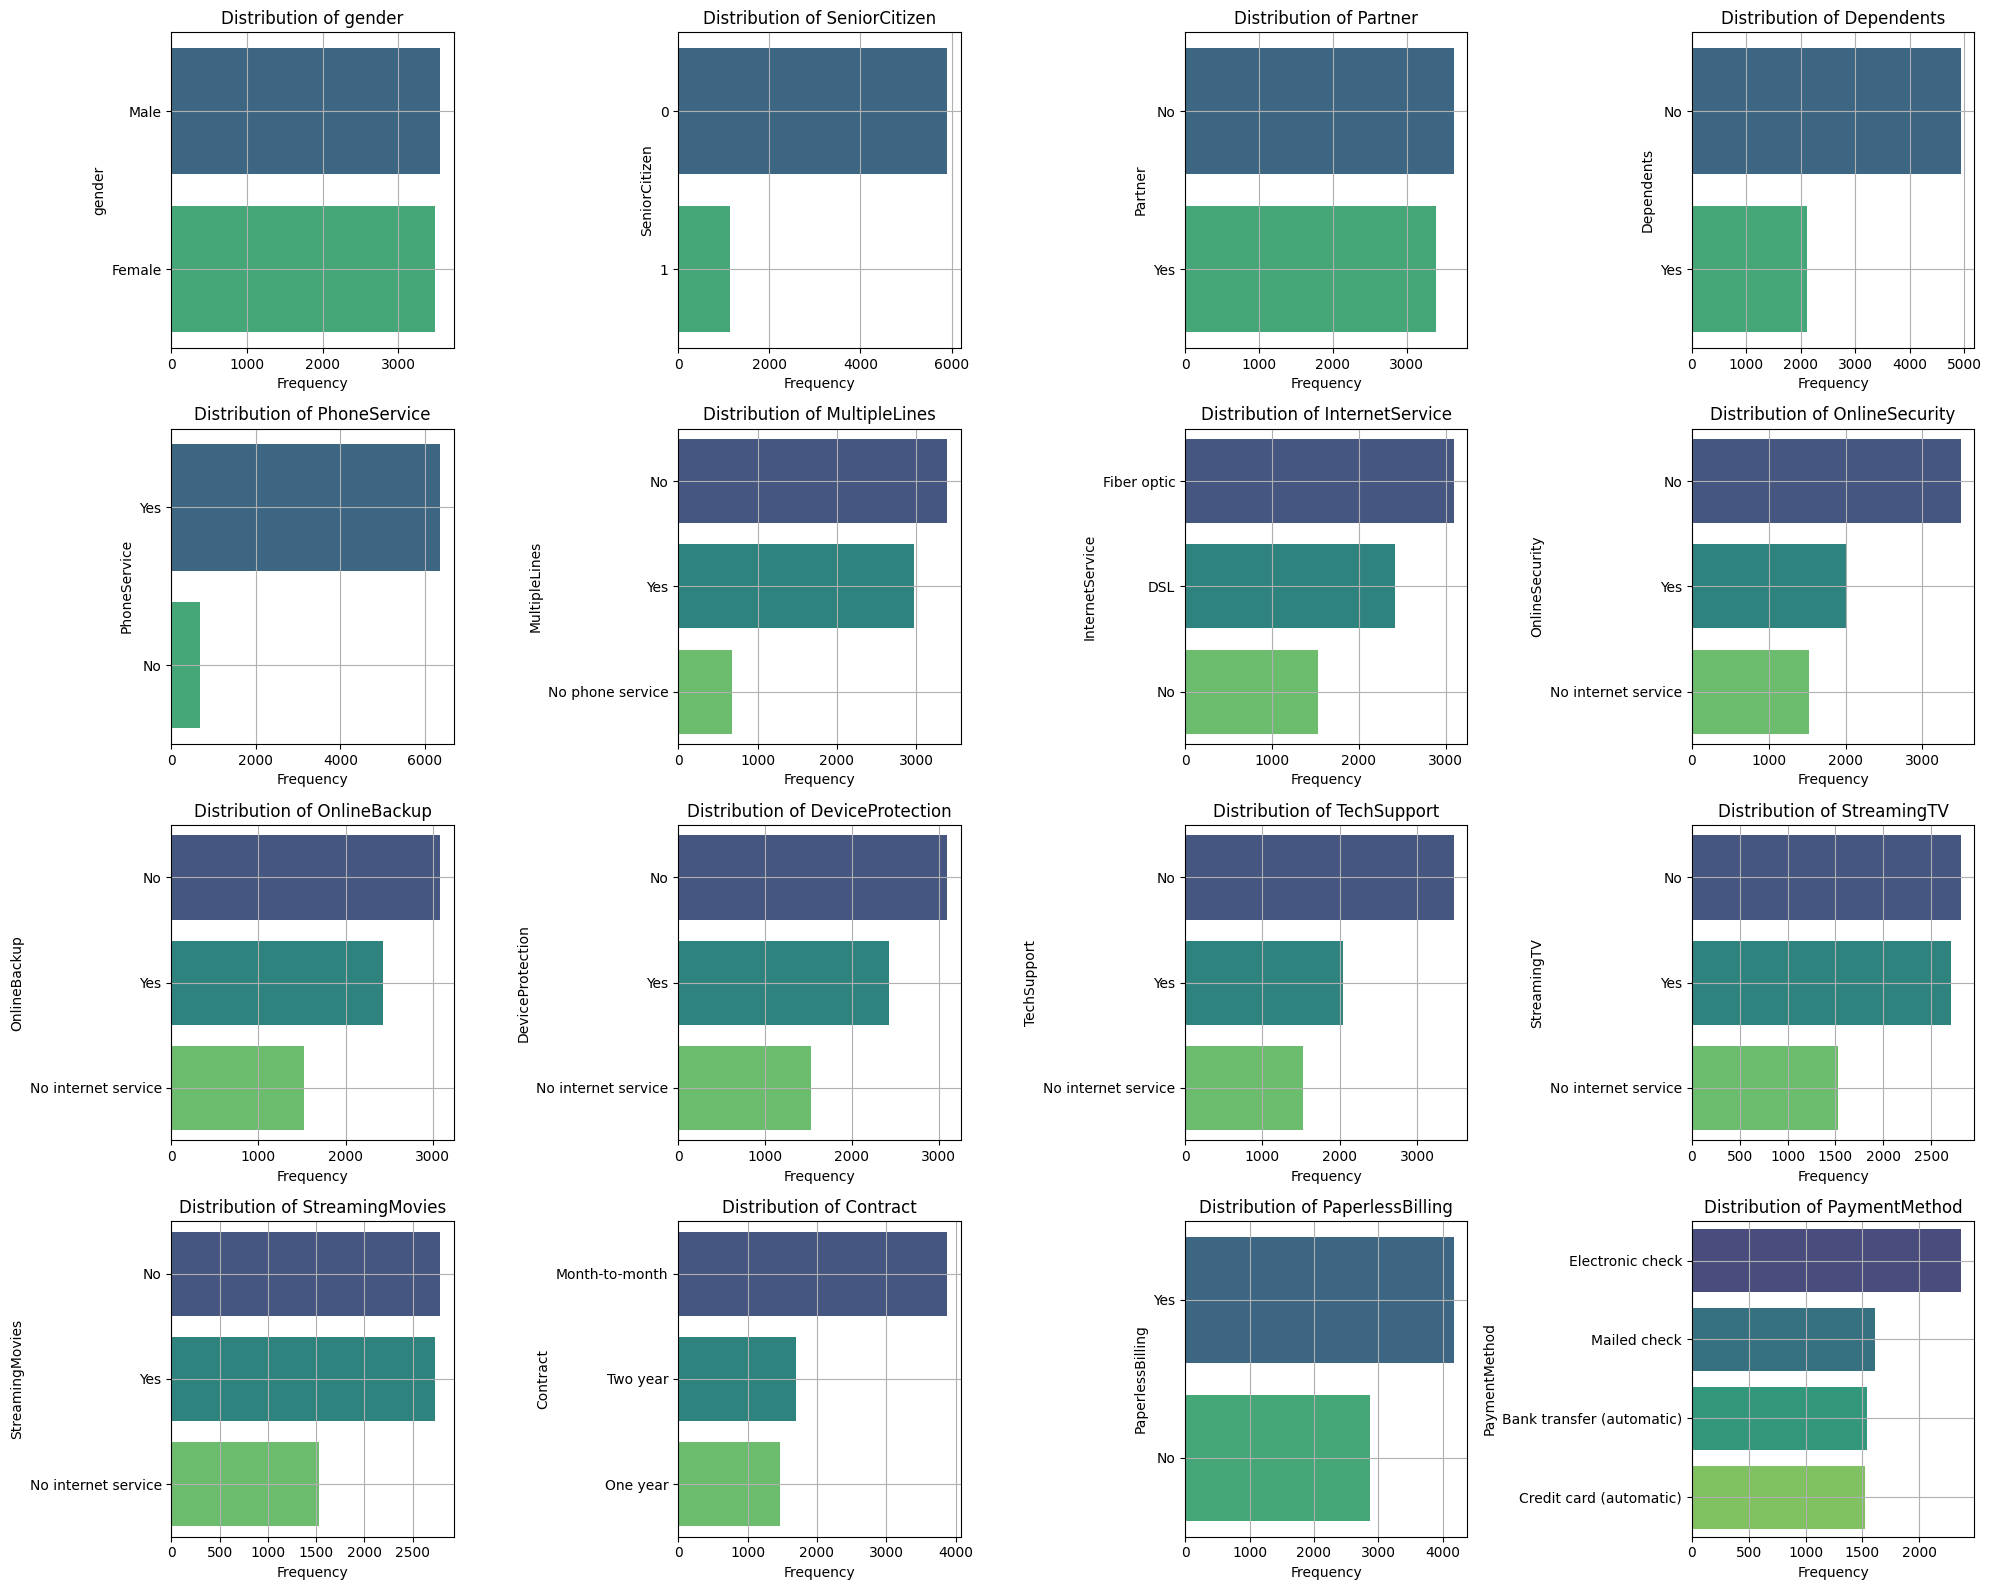

In [ ]:
plot_all_categorical(df, cols=4, features=CATEGORICAL_FEATURES_LIST)

**gender**:
- количество мужчин и женщин почти равное

**SeniorCitizen**:
- большинство клиентов не пенсионеры

**Partner**:
- наличие или же отсутствие супруга(и) примерное равны

**Dependents**:
- у большинства нет иждевенцев

---

**PhoneService**:
- у большинства клиентов подключена телефонная связь

**MultipleLines**:
- примерно у половины клиентов кто пользуется телефонной связью есть услуга "нескольких линий"

---

**InternetService**:
- примерно у 1/3 клиентов не подключен интернет, у оставшихся DSL / Fiber optic почти поровну

**У клиентов с подключенным интернетом:**

**OnlineSecurity**:
- клиентов с функцией OnlineSecurity в 2 раза меньше чем без нее

**OnlineBackup**:
- клиентов с функцией OnlineBackup немного меньше чем без нее

**DeviceProtection**:
- клиентов с функцией DeviceProtection немного меньше чем без нее

**TechSupport**:
- клиентов с функцией TechSupport в 2 раза меньше чем без нее

**StreamingTV**:
- клиентов с функцией StreamingTV столько же сколько и без нее

**StreamingMovies**:
- клиентов с функцией StreamingMovies столько же сколько и без нее

---

**Contract**:
- около половины клиентов имеют ежемесячный тип контракта (Month-to-month), у остальных примерно поровну годовой (One year) и двух годовой (Two year) тип контрактов

**PaperlessBilling**:
- около 60% клиентов используют получают счета в электронном виде

**PaymentMethod**:
- большинство клиентов предпочитает использовать способ оплаты Electronic check, остальные методы равны по популярности(Mailed check/Bank transfer/Credit card)

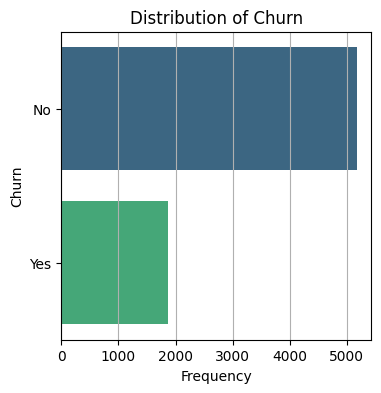

In [ ]:
plot_hist_categorical(df, TARGET)

In [ ]:
df[TARGET].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Только в 26% случаев клиент уходит -> Несбалансированный датасет. Необходимо применять техники балансировки

## 4. Изучение взаимосвязей между признаками

### 4.1 Общая матрица корреляций

In [ ]:
# удаляем столбец customerID, поскольку он не несет пользы в дальнейшем исследовании
df = df.drop(columns=['customerID'])

interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


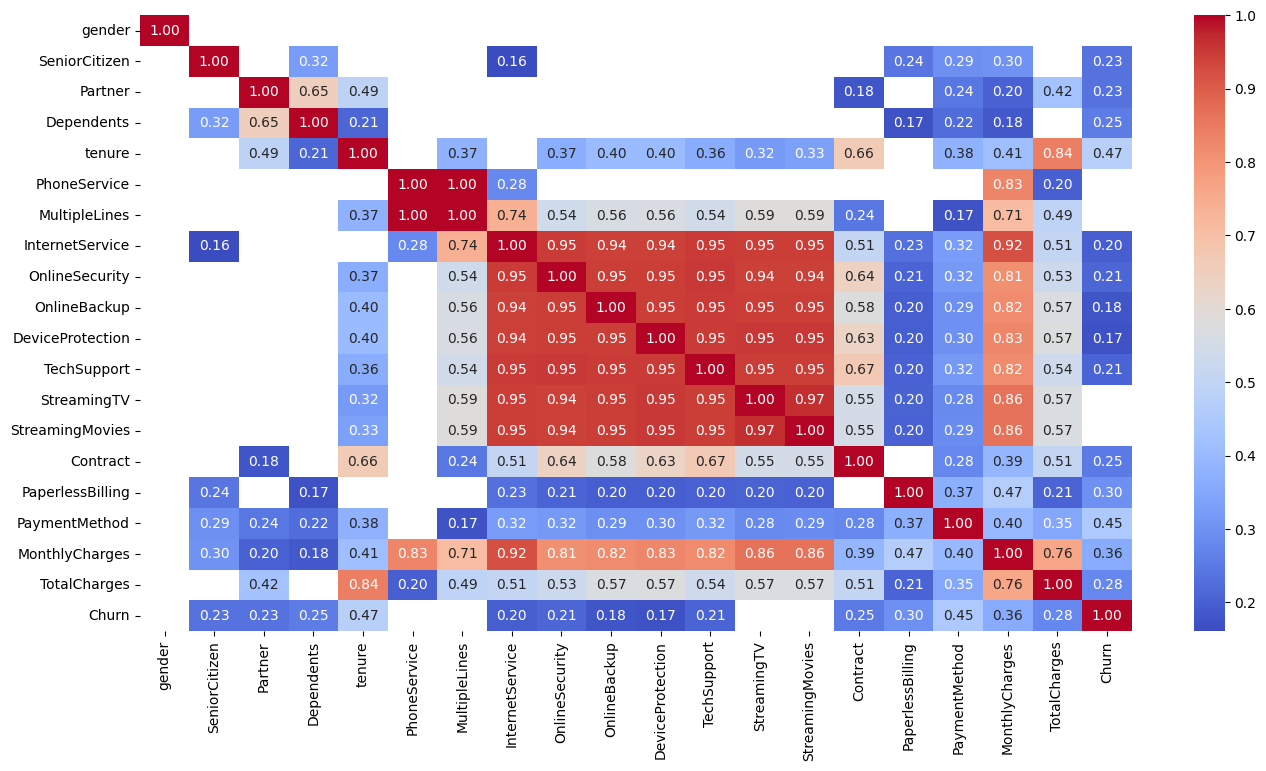

In [ ]:
plot_phik(df, figsize=(16, 8), threshold=0.15)

- Группа признаков вокруг *InternetService*, *OnlineSecurity*, *OnlineBackup*, *DeviceProtection*, *TechSupport*, *StreamingTV*, *StreamingMovies* имеет очень высокие связи (0.9+). Это означает сильную избыточность: эти поля описывают один и тот же скрытый фактор - тип интернет‑услуг у клиента.

- *MonthlyCharges* сильно коррелирует с *PhoneService*, *MultipleLines*, *InternetService*, *OnlineSecurity*, *OnlineBackup*, *DeviceProtection*, *TechSupport*, *StreamingTV*, *StreamingMovies* (≈0.7–0.86). Больше услуг - выше платеж.

- *MultipleLines* и *PhoneService* почти полностью дублируют друг друга (корреляция = 1). Один из них можно убрать.

- *MultipleLines* и *InternetService* высоко коррелируют (0.74).

- Связь *Contract* с признаками интернет‑услуг выше средней (0.5–0.67). Тип контракта явно связан с выбранными сервисами.

- *MonthlyCharges* и *TotalCharges* ожидаемо сильно коррелируют (0.76). Тоже частично дублируют друг друга.

- *Tenure* связан с *Contract* (0.66), *TotalCharges* (0.84). Чем дольше клиент, тем выше накопленные траты, и тем чаще у него долгосрочный контракт.

- *gender* - практически не связан ни с чем.

- Связь признаков с *Churn*:
  - Наиболее связаны: *tenure* (0.47), *PaymentMethod* (0.45), *MonthlyCharges* (0.36), *PaperlessBilling* (0.3), .  

### 4.2 Подробное изучение корреляций между выбранными парами

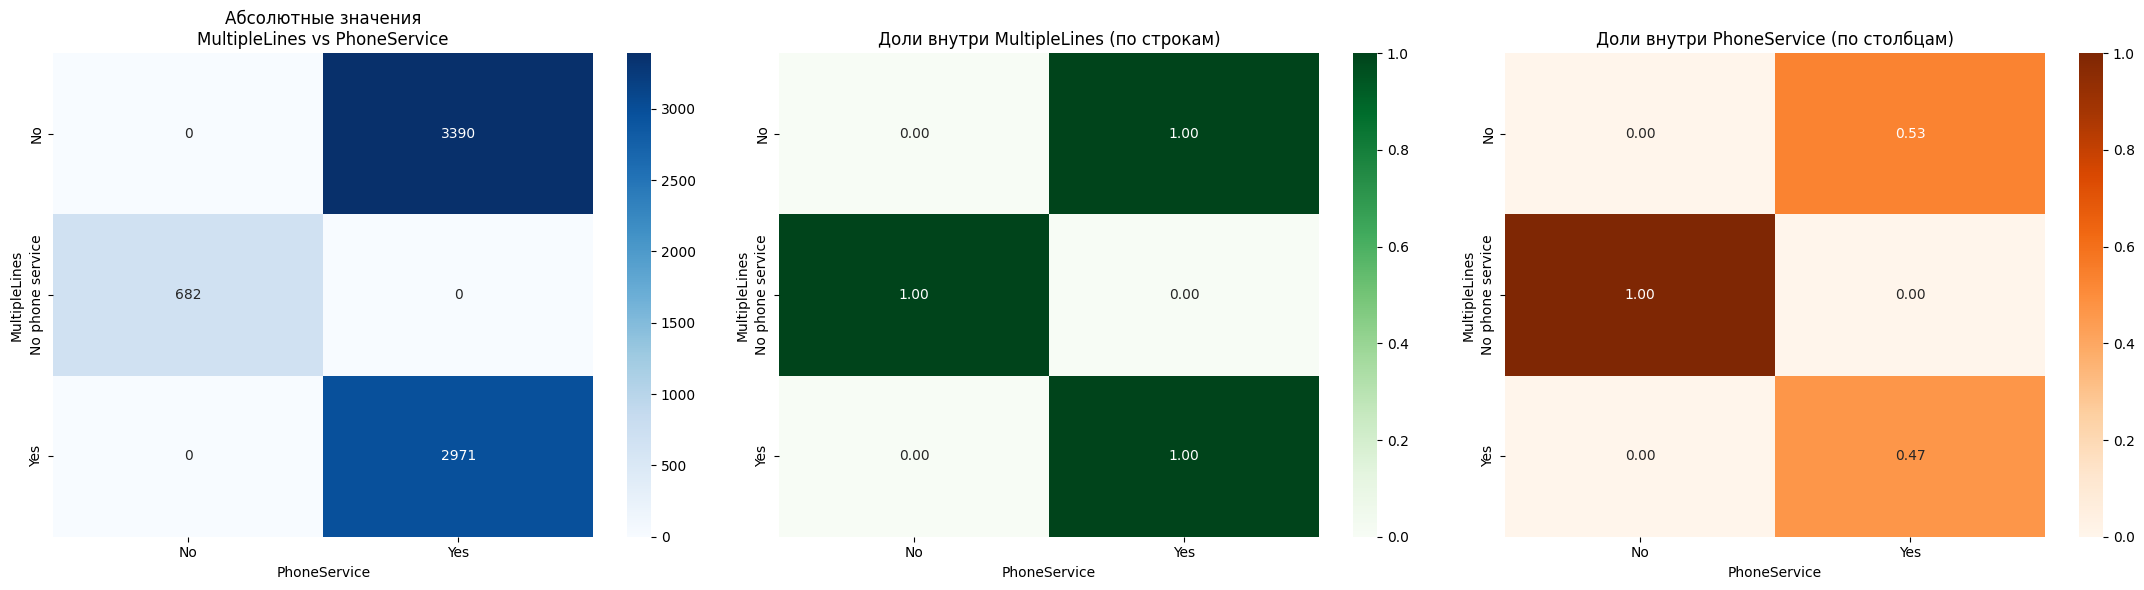

In [ ]:
plot_categorical_relationship(df, 'MultipleLines', 'PhoneService')

По сути признаки дублируют друг-друга. Имеет смысл удалить PhoneService 

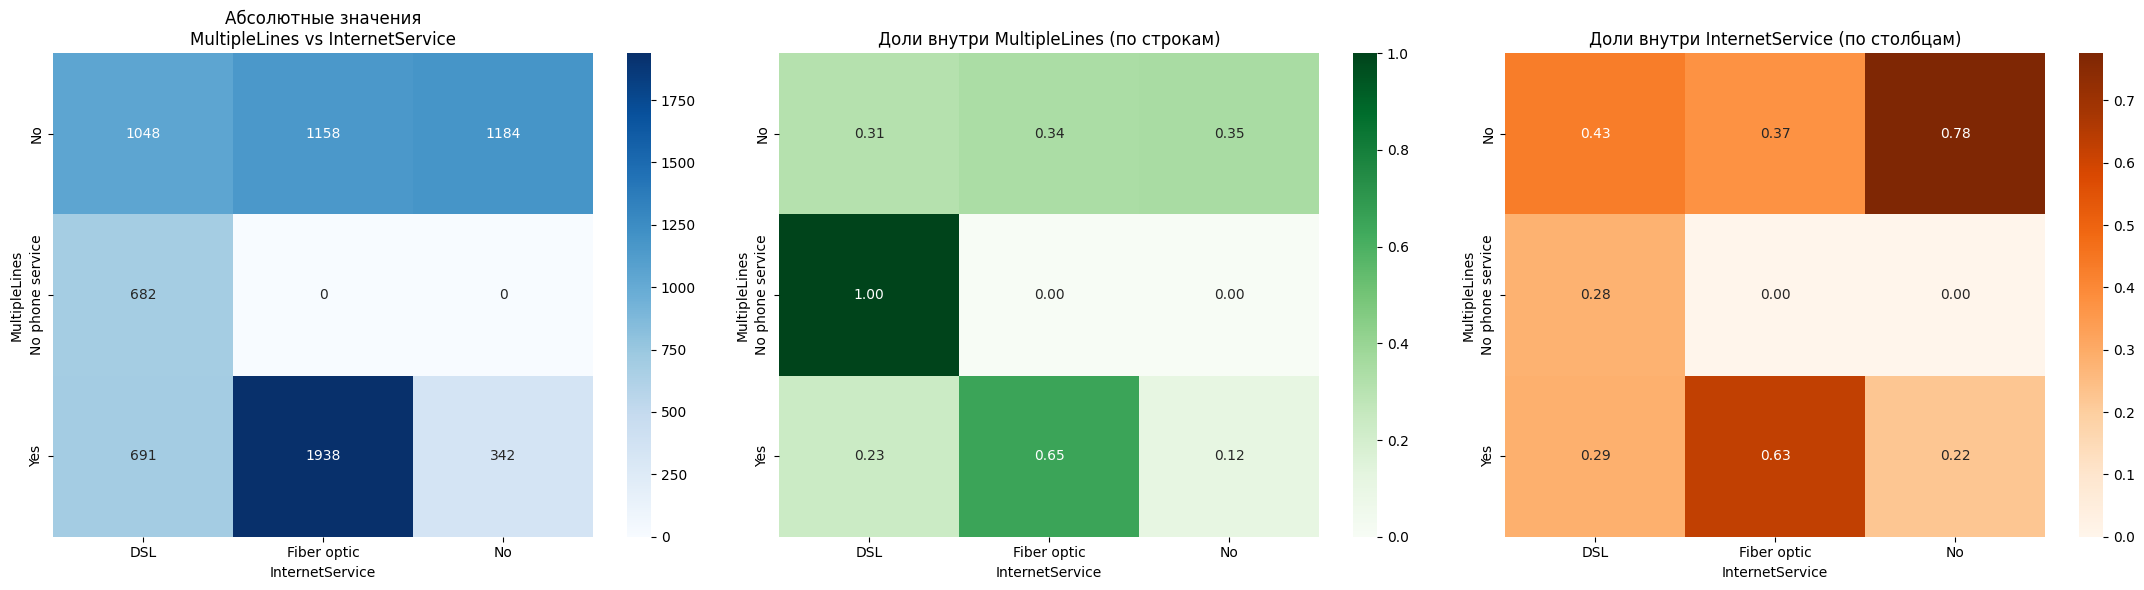

In [ ]:
plot_categorical_relationship(df, 'MultipleLines', 'InternetService')

- Подключение Fiber optic сильно связано с наличием MultipleLines = Yes: пользователи оптоволокна чаще имеют дополнительные телефонные линии.

- Клиенты с No phone service встречаются только в DSL.

- Пользователи без интернета чаще не имеют multiple lines.

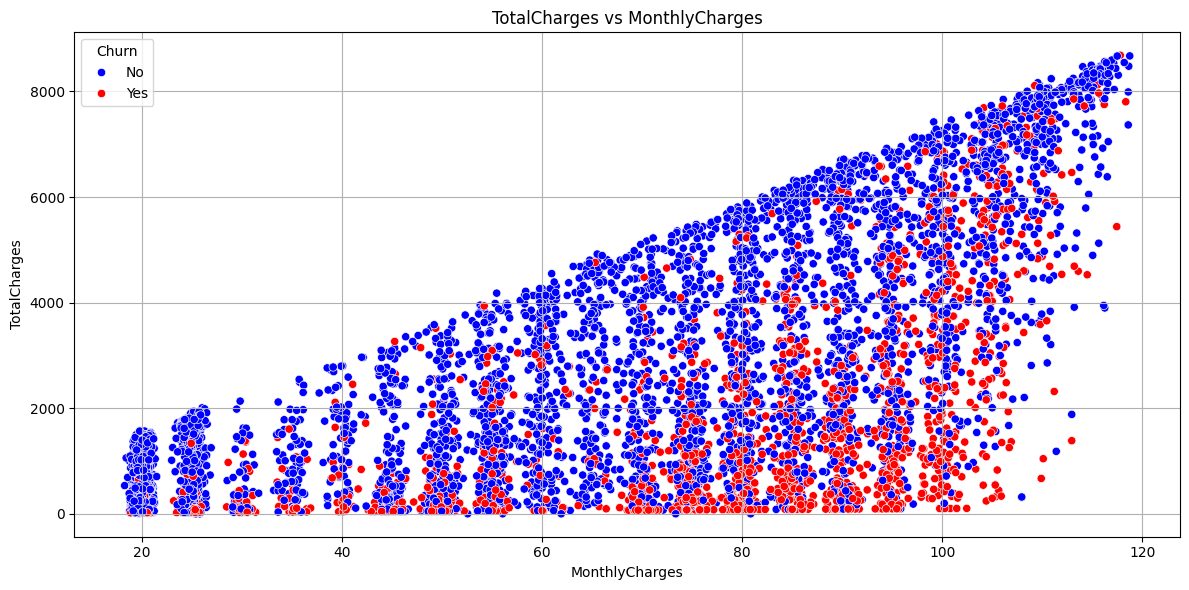

In [ ]:
plot_numeric_relationship(
    df, 
    x_col='MonthlyCharges', 
    y_col='TotalCharges',
    target_col=TARGET, 
    figsize = (12, 6)
)

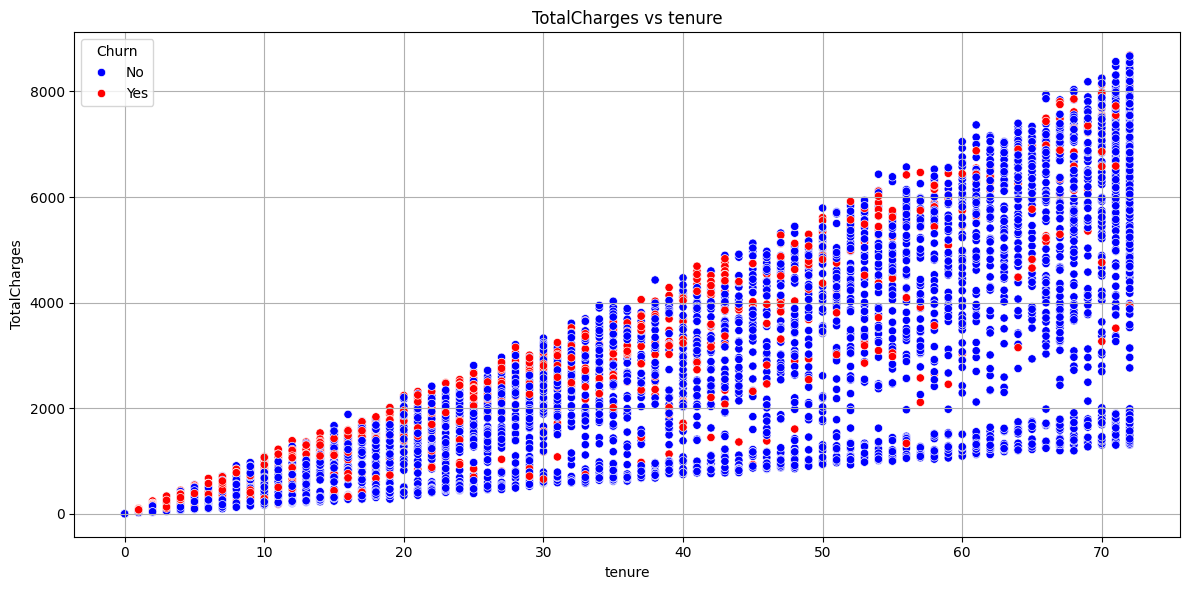

In [ ]:
plot_numeric_relationship(
    df, 
    x_col='tenure', 
    y_col='TotalCharges',
    target_col=TARGET, 
    figsize = (12, 6)
)

Присутствует Гетероскедастичность и Линейный тренд. 

Можно применить логарифмирование к признаку *TotalCharges* или использовать модели, менее чувствительные к гетероскедастичности (деревья).

<string>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



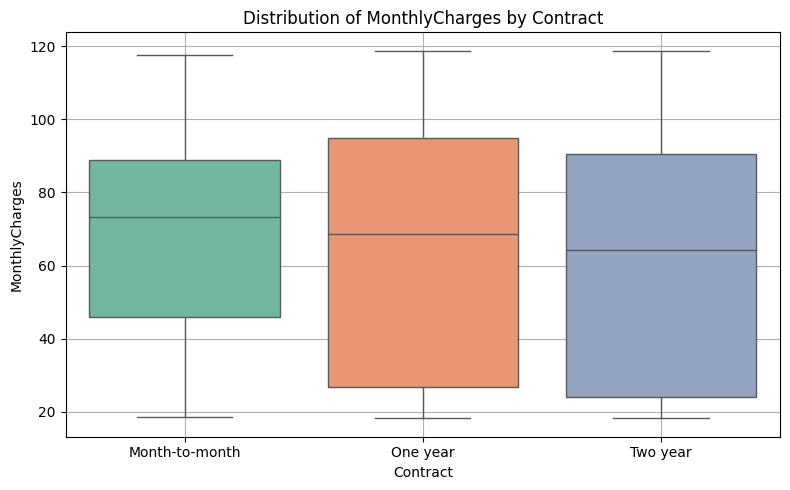

In [ ]:
plot_numeric_vs_categorical_boxplot(df, 
                                    numerical_feature="MonthlyCharges", 
                                    categorical_feature="Contract",
                                    figsize=(8, 5),
                                    )

<string>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



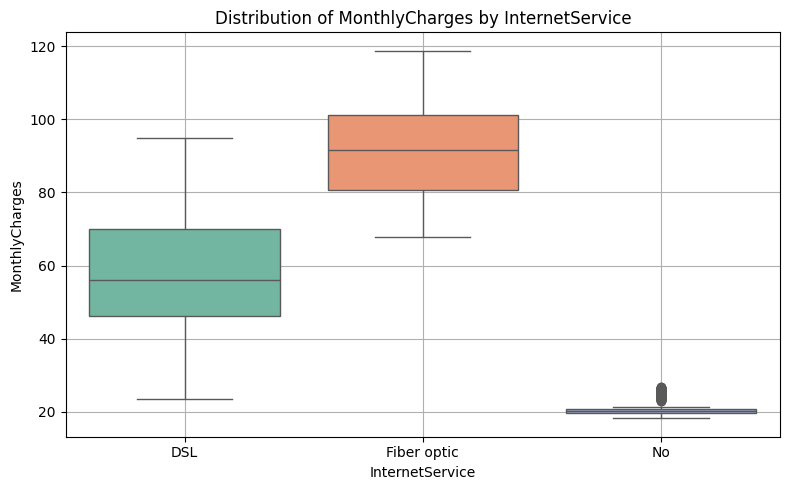

In [ ]:
plot_numeric_vs_categorical_boxplot(df, 
                                    numerical_feature="MonthlyCharges", 
                                    categorical_feature="InternetService",
                                    figsize=(8, 5),
                                    )

- Признак MonthlyCharges сильно зависит от InternetService. Значит, эти два признака связаны и зависимы.
- Клиенты с Fiber optic платят заметно больше. Это делает их потенциально более уязвимыми к оттоку, если высокая стоимость связана с неудовлетворённостью.
- Группа No internet имеет почти константное значение MonthlyCharges.

<string>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



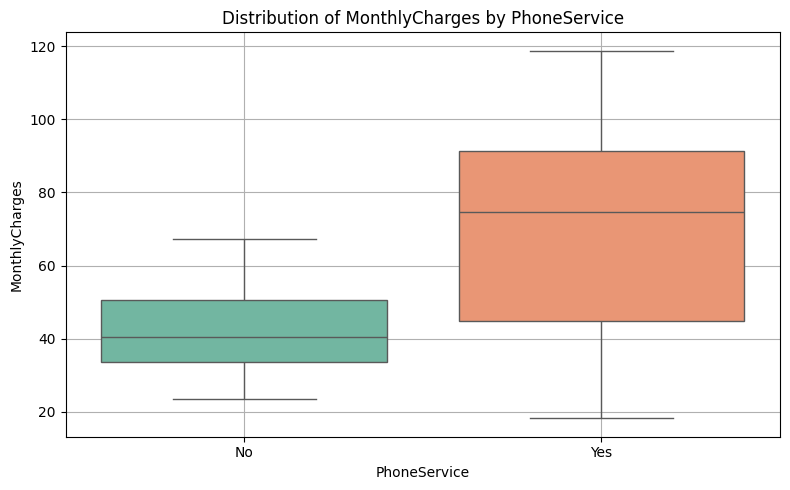

In [ ]:
plot_numeric_vs_categorical_boxplot(df, 
                                    numerical_feature="MonthlyCharges", 
                                    categorical_feature="PhoneService",
                                    figsize=(8, 5),
                                    )

- Клиенты с PhoneService = Yes платят заметно больше.
- Клиенты без PhoneService имеют более узкий диапазон (~25–65) и ниже медиану (~40).
- PhoneService влияет на MonthlyCharges.

<string>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



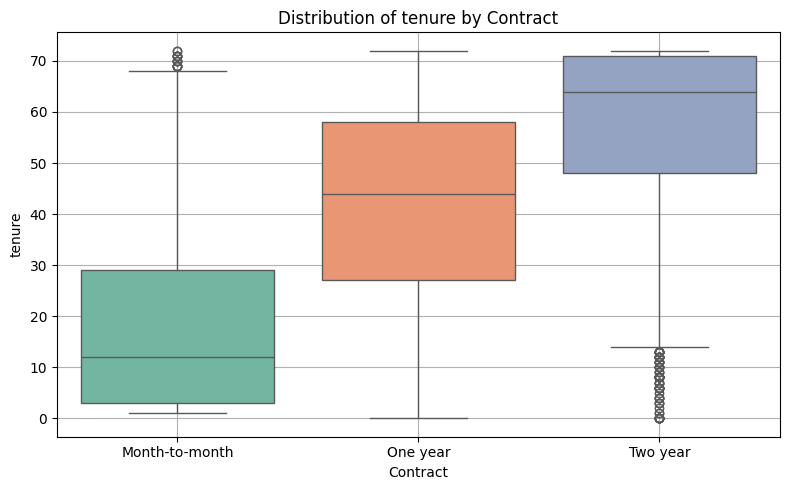

In [ ]:
plot_numeric_vs_categorical_boxplot(df, 
                                    numerical_feature="tenure", 
                                    categorical_feature="Contract",
                                    figsize=(8, 5),
                                    )

- Клиенты с помесячным контрактом имеют самое маленький tenure (количество времени с компанией) и самый большой разброс — это более «нестабильная» группа.
- Годовые и особенно двухгодичные контракты связаны с существенно большим tenure.
- Чем длиннее контракт, тем выше средний tenure - это указывает на более высокую лояльность.
- Тип контракта является сильным предиктором поведения клиента и вероятно важным признаком для моделей.

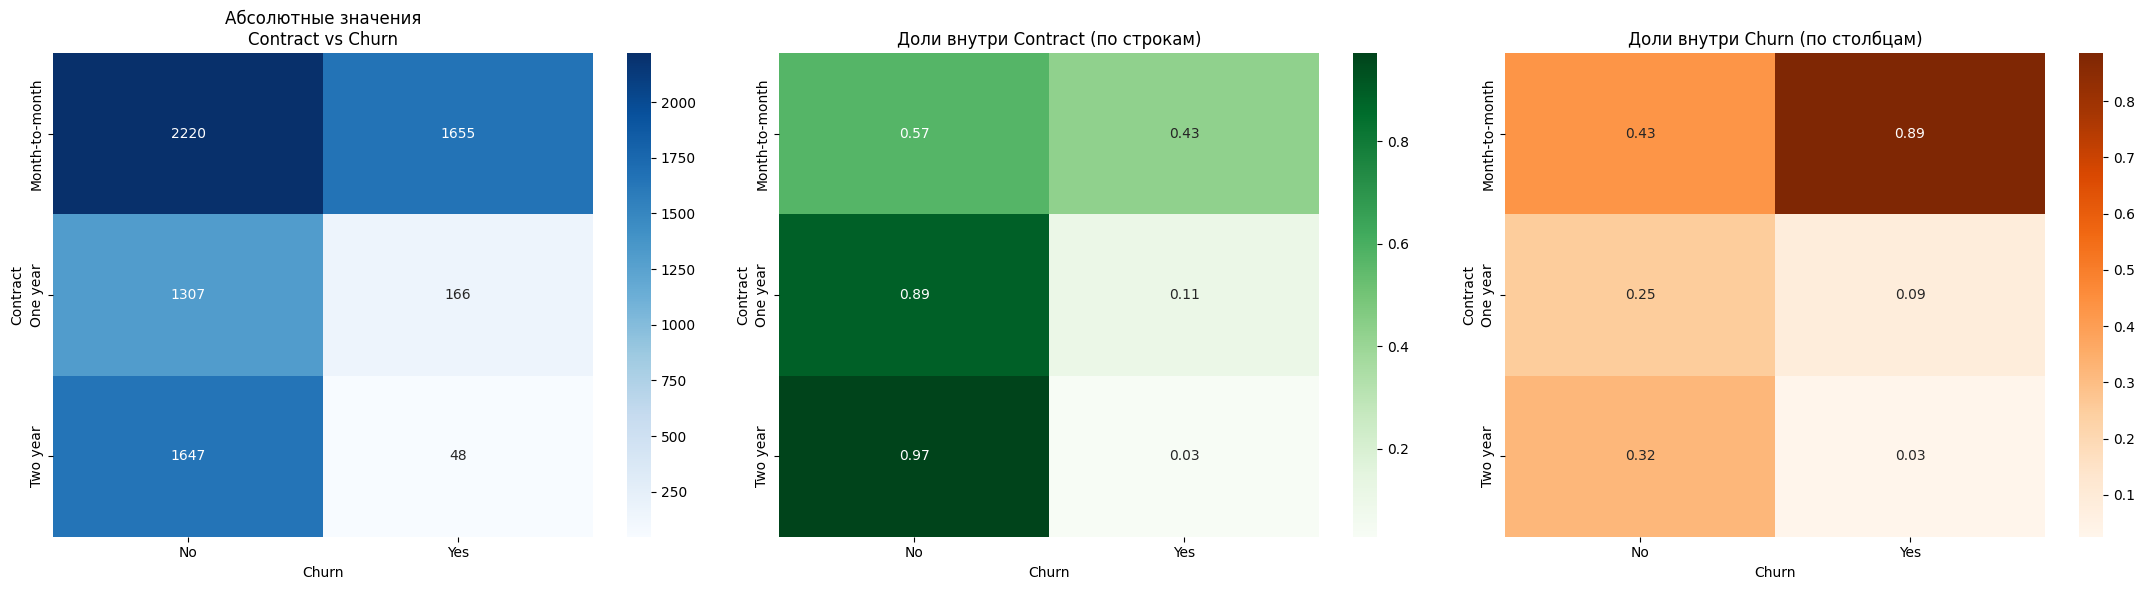

In [ ]:
plot_categorical_relationship(df, 'Contract', 'Churn')

89% ушедших клиентов использовали ежемесячную подписку

<string>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



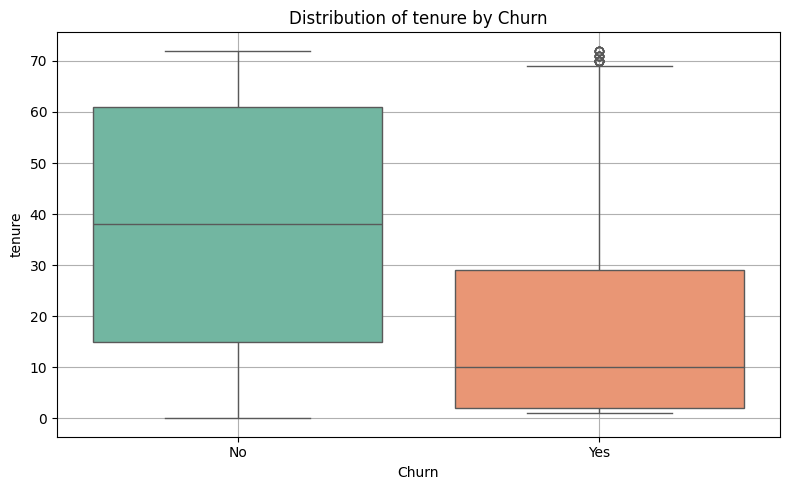

In [ ]:
plot_numeric_vs_categorical_boxplot(df, 
                                    numerical_feature="tenure", 
                                    categorical_feature="Churn",
                                    figsize=(8, 5),
                                    )

- Клиенты, которые остаются (Churn = No), в среднем имеют значительно больший срок обслуживания (tenure).  
- У клиентов, которые уходят (Churn = Yes), tenure заметно меньше, медиана - в разы ниже.  

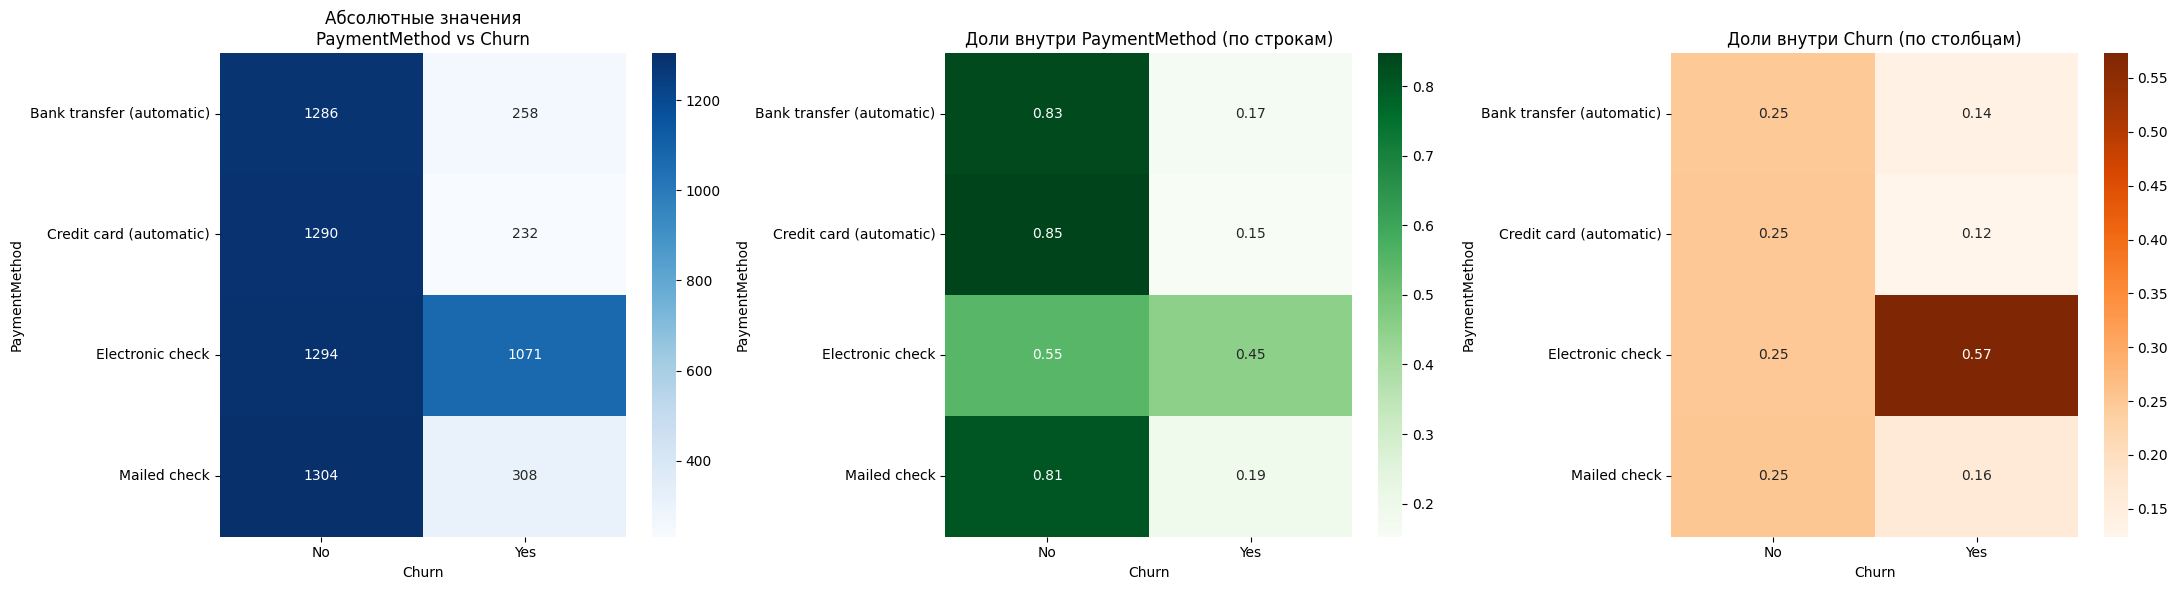

In [ ]:
plot_categorical_relationship(df, 'PaymentMethod', 'Churn')

- Наибольший вклад в отток дает Electronic check - почти половина клиентов, использующих этот метод, уходят.
- Методы оплаты с mailed check, bank transfer, credit card связаны с низким уровнем оттока.

## Выводы

- Изначально в датасете признак **TotalCharges** имел неправильный тип данных object вместо float64. После конвертации обнаружились пропуски, которые нужно заполнить 0. Везде где столбец TotalCharges имел пропуски, Tenure (количество месяцев с компанией) равно 0.

- В остальных признаках датасет не имеет пропусков и дубликатов.

- Отрицательных значений нет. Лишних значений в категориальных признаках нет.

- Распределение признака **TotalCharges** (общая сумма платежей клиента за всё время обслуживания) имеет **сильную положительную асимметрию (правосторонняя)**. Использовать **логарифмическое преобразование** для симметризации.

- Признаки **tenure** и **MonthlyCharges** можно попробовать разбить на несколько групп (биннинг)

- Группа признаков **InternetService**, **OnlineSecurity**, **OnlineBackup**, **DeviceProtection**, **TechSupport**, **StreamingTV**, **StreamingMovies** имеет очень высокие связи (0.9+). Это означает сильную избыточность: эти поля описывают один и тот же скрытый фактор - тип интернет‑услуг у клиента.

- **MonthlyCharges** и **TotalCharges** ожидаемо сильно коррелируют (0.76). Частично дублируют друг друга.

- **MonthlyCharges**, в отличие от **TotalCharges** сильно коррелирует с **PhoneService**, **MultipleLines**, **InternetService**, **OnlineSecurity**, **OnlineBackup**, **DeviceProtection**, **TechSupport**, **StreamingTV**, **StreamingMovies** (≈0.7–0.86). Больше услуг - выше платеж.

- **MultipleLines** и **PhoneService** почти полностью дублируют друг друга (корреляция = 1). Один из них можно убрать.

- **MultipleLines** и **InternetService** высоко коррелируют (0.74).

- **Tenure** связан с **Contract** (0.66), **TotalCharges** (0.84). Чем дольше клиент, тем выше накопленные траты, и тем чаще у него долгосрочный контракт.

- **gender** - пол практически не связан с другими признаками.

- Для категориальных признаков можно использовать **LabelEncoder**.

- Для числовых применить нормализацию.

- Наиболее коррелированные признаки с таргетом **Churn**: 
  - **tenure** (0.47) - Клиенты, которые остаются (*Churn = No*), в среднем имеют значительно больший срок обслуживания
  - **PaymentMethod** (0.45) - Наибольший вклад в отток дает *Electronic check* - почти половина клиентов, использующих этот метод оплаты, уходят

- Несбалансированный target **Churn** (26% случаев клиент уходит). Необходимо применять техники балансировки